In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True) #for figures

In [2]:
#Read panNEC anndata: 
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata= sc.read_h5ad(results)

#Rename clusters a/c current annotations:
adata.obs['Cell states'] = (adata.obs["Cell states"].map(lambda x: {"Neuroendocrine EEC-like01": "Amphicrine progenitor-like",
                    "Neuroendocrine EEC-like02": "Neuroendocrine",
                    "Neuroendocrine HSP+": "Neuroendocrine HSP+ (hypoxic)"}.get(x, x)).astype("category"))

adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

In [3]:
#!mkdir panNEC_QC_files

In [4]:
#Cluster categories: 
adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

In [5]:
#Get the full length matrix for visualizing all markers
adata_norm= adata.raw.to_adata()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

#### Supplementary Figure 7a: markers capturing robustness & specificity of P5 clusters 

None of the pancreatic lineage markers are present in the shared panNEC clusters. 

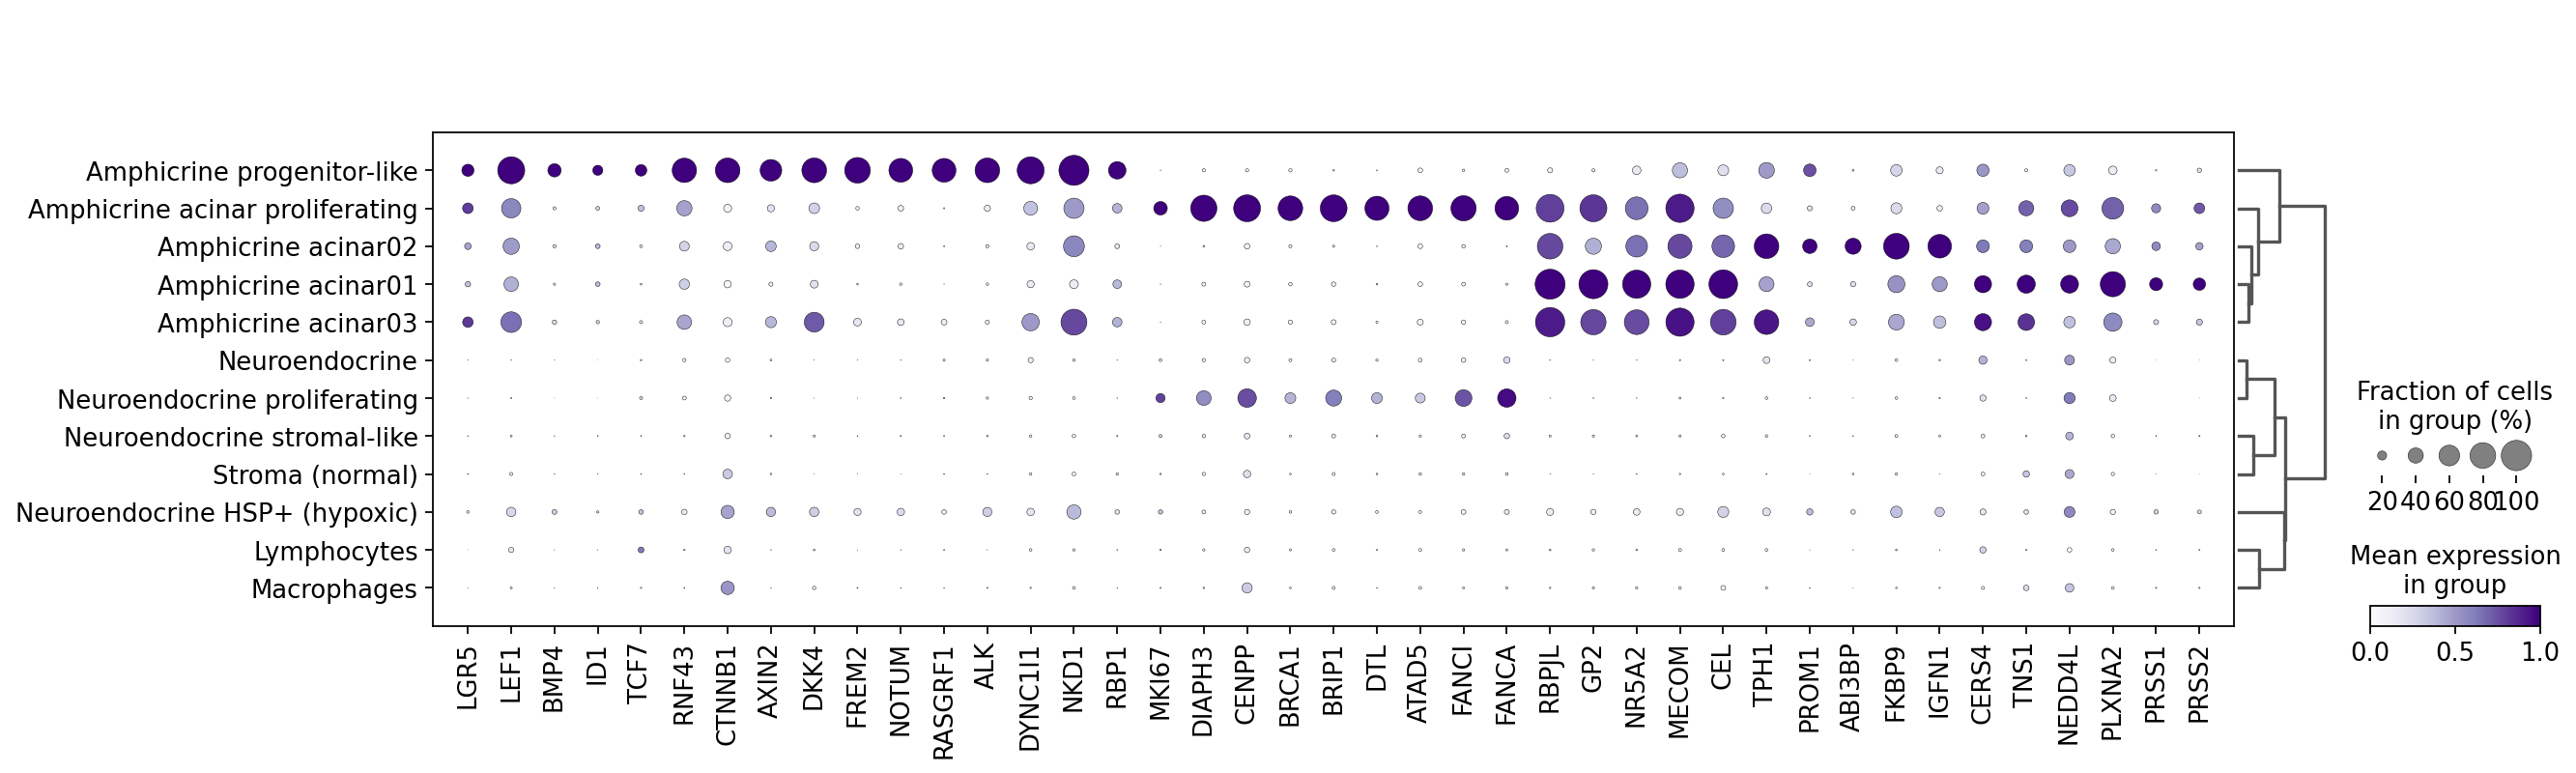

In [6]:
#Reference: Supplementary Data 2. 
#Core proliferating markers are common to NE_prol & amphicrine acinar prol 
#Many key acinar/amphicrine markers biology are described in the Supplementary Material associated with the paper 
sc.pl.dotplot(adata_norm, ['LGR5', 'LEF1', 
            'BMP4', 'ID1', 'TCF7', 'RNF43', 'CTNNB1', 'AXIN2', 'DKK4', 
            'FREM2', 'NOTUM', 'RASGRF1', 'ALK', 'DYNC1I1', 'NKD1', 
            'RBP1', 'MKI67', 'DIAPH3', 'CENPP', 'BRCA1', 'BRIP1', 'DTL', 'ATAD5', 'FANCI', 'FANCA', #amphicrine prol 
            'RBPJL', 'GP2', 'NR5A2', 'MECOM', 'CEL', 
            'TPH1', 'PROM1', 'ABI3BP', 'FKBP9', 'IGFN1', 'CERS4', 'TNS1', 'NEDD4L', 'PLXNA2', 'PRSS1', 'PRSS2'], 
            groupby= "Cell states", dendrogram=True, standard_scale= "var", color_map= "Purples", swap_axes=False, 
            save= "_SupplFigure7A_amphicrine_markers_v2_16072025.pdf") 

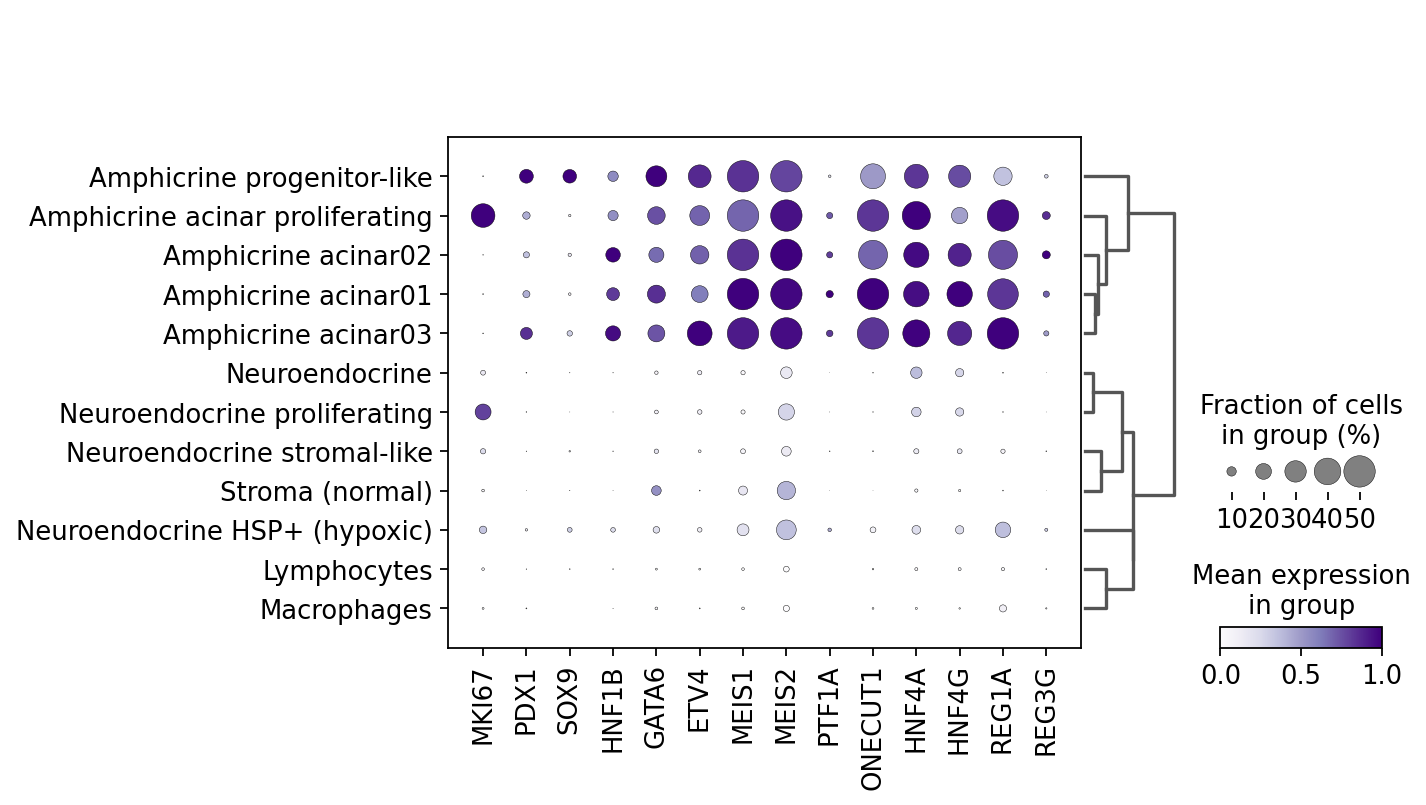

In [7]:
#Does Tosti et al. acinar REG+ markers map to any of our clusters?! 
sc.pl.dotplot(adata_norm, ['MKI67', 'PDX1', 'SOX9','HNF1B', 'GATA6', 'ETV4',
                           'MEIS1', 'MEIS2','PTF1A', 'ONECUT1', 'HNF4A', 'HNF4G', 'REG1A', 'REG3G'], 
            groupby= "Cell states", dendrogram=True, dot_max=0.5, 
            standard_scale= "var", color_map= "Purples", swap_axes=False, 
            save= "_AcinarREG_amphicrine_16072025.pdf") #Not shown in the final S.I 

#REG1A is relatively robust & specific across amphicrine acinar clusters. 

In [8]:
#Subset only the tumor cells:
adata_sub= adata_norm[adata_norm.obs['Cell types']!= "Immune"]
adata_sub.obs['Cell types'].cat.categories

Index(['Neuroendocrine', 'Amphicrine acinar', 'Stroma (normal)'], dtype='object')

In [9]:
#Only subset amphicrine sub-groups:
adata_new= adata_sub[adata_sub.obs['Cell states'].isin(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like'])]

adata_new.obs['Cell states'].value_counts()

Amphicrine acinar01                7047
Amphicrine acinar03                5840
Amphicrine acinar02                2424
Amphicrine progenitor-like         1488
Amphicrine acinar proliferating     735
Name: Cell states, dtype: int64

In [10]:
sc.pp.normalize_total(adata_new, target_sum=1e4)
sc.pp.log1p(adata_new)

/home/debnatho/anaconda3/envs/scvi_analysis/lib/python3.7/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [11]:
sc.tl.rank_genes_groups(adata_new, groupby='Cell states', method='wilcoxon')
sc.tl.dendrogram(adata_new, groupby= "Cell states")

In [12]:
del adata_new

In [13]:
#We want to compute subgroup specific markers just for broadly distinguishing 3 acinar states. 
#We excluded "amphicrine progenitor-like" as we have enough selective markers to stratify it. 
adata_new= adata_sub[adata_sub.obs['Cell states'].isin(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03'])]

adata_new.obs['Cell states'].value_counts()

Amphicrine acinar01    7047
Amphicrine acinar03    5840
Amphicrine acinar02    2424
Name: Cell states, dtype: int64

In [14]:
sc.pp.normalize_total(adata_new, target_sum=1e4)
sc.pp.log1p(adata_new)

/home/debnatho/anaconda3/envs/scvi_analysis/lib/python3.7/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [15]:
#Ran Wilcoxon rank sum test implemented in Scanpy 
##Reference: Supplementary Data 2 (Sheet 2; Amphicrine subcluster markers)
sc.tl.rank_genes_groups(adata_new, groupby='Cell states', method='wilcoxon')
sc.tl.dendrogram(adata_new, groupby= "Cell states")

In [16]:
adata_new

AnnData object with n_obs × n_vars = 15311 × 32873
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'orig_cell_id', 'sample_id_final', 'group', 'sample_label', 'nCount_RNA.orig', 'nFeature_RNA.orig', 'percent_mito', 'percent_ribo', 'CellFilterKeep', 'patID', 'batch', 'seurat_clusters', 'cluster_label_Tosti_combined', 'cluster_type_Tosti_combined', 'cluster_label_single_MV', 'source_label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_MT_genes', 'log1p_total_counts_MT_genes', 'pct_counts_MT_genes', 'total_counts_Ribo_genes', 'log1p_total_counts_Ribo_genes', 'pct_counts_Ribo_genes', 'total_counts_HB_genes', 'log1p_total_counts_HB_genes', 'pct_counts_HB_genes', 'percent_mt2', 'n_counts', 'percent_Ribo2', 'percent_HB2', 'S_score', 'G2M_score', 'phase', 'XIST-counts', 'res_1', 'res_0.5', 'Cycling (S)', 'Cycling (G2/M)', 'MYC signaling', 'Adhesive', 'Ribosomal', 'Interferon signaling', 'TNF-NFkB signaling', 'Acinar-like', 'Classical-

#### Supplementary Figure 7b: subcluster markers capturing heterogeneity among P5 amphicrine acinar cell states

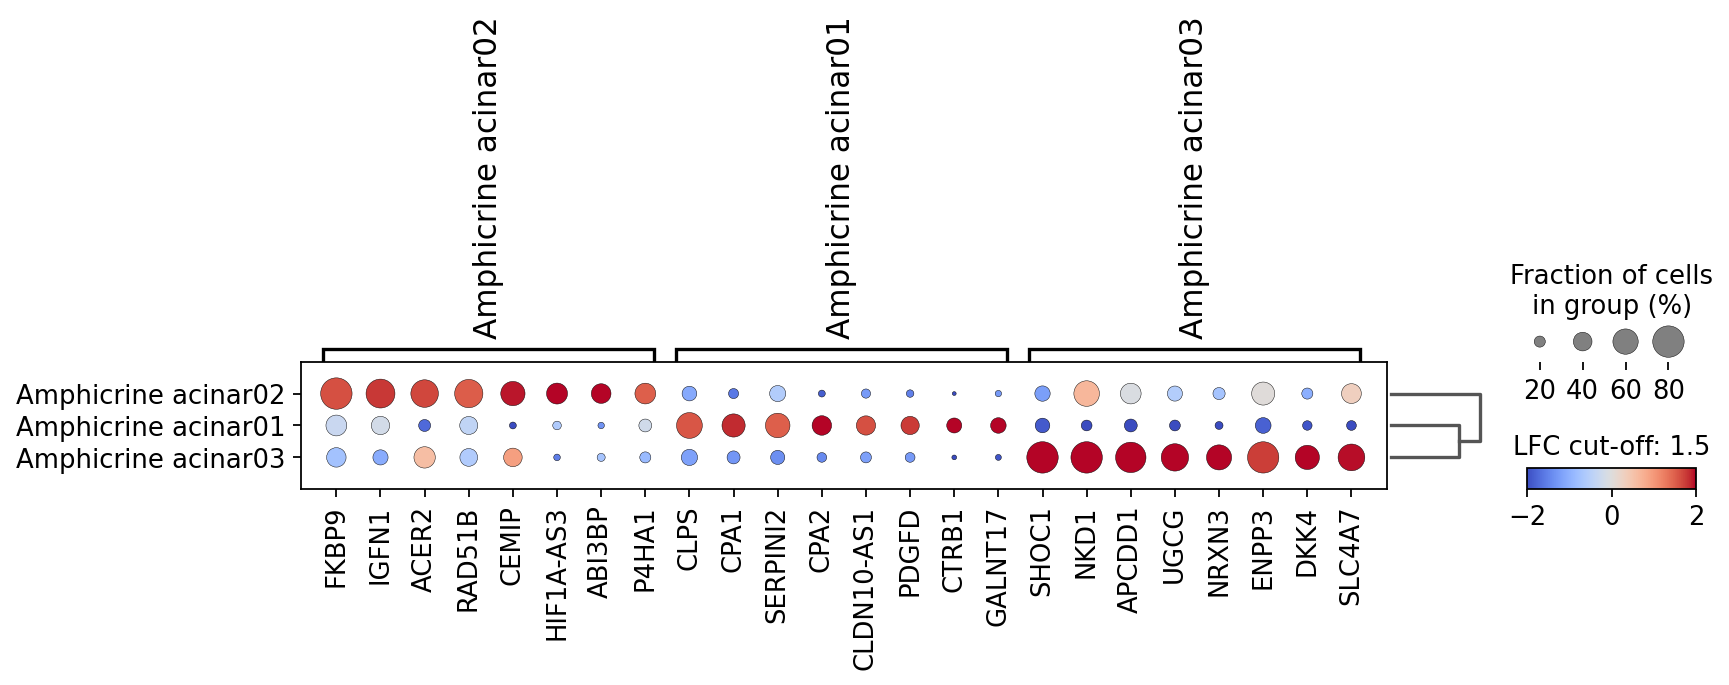

In [17]:
sc.pl.rank_genes_groups_dotplot(adata_new,
    n_genes=8,
    values_to_plot="logfoldchanges", cmap='coolwarm',
    dot_max=0.8, 
    vmin=-2,
    vmax=2,
    min_logfoldchange=1.5,
    colorbar_title='LFC cut-off: 1.5', 
    save= "_AM_acinar_subcluster_markers_16072025.pdf") 

In [18]:
adata_new.uns["rank_genes_groups"]

{'params': {'groupby': 'Cell states',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('GP2', 'FKBP9', 'SHOC1'), ('PLXNA2', 'IGFN1', 'NKD1'),
            ('UST', 'ACER2', 'APCDD1'), ..., ('ENPP3', 'GP2', 'IL1RAPL1'),
            ('APCDD1', 'SLC38A11', 'MTCL1'), ('NKD1', 'CNTNAP2', 'PAPPA2')],
           dtype=[('Amphicrine acinar01', 'O'), ('Amphicrine acinar02', 'O'), ('Amphicrine acinar03', 'O')]),
 'scores': rec.array([( 45.481544,  36.191692,  57.492542),
            ( 44.178696,  34.512074,  51.65299 ),
            ( 41.61565 ,  31.764137,  48.90352 ), ...,
            (-43.40677 , -37.122295, -38.4254  ),
            (-47.910686, -37.218567, -38.989098),
            (-61.06231 , -39.023895, -39.359646)],
           dtype=[('Amphicrine acinar01', '<f4'), ('Amphicrine acinar02', '<f4'), ('Amphicrine acinar03', '<f4')]),
 'pvals': rec.array([(0., 8.22502913e-287, 0.), (0., 5.28618791e-26

In [19]:
#Consolidate results into a dataframe: 
result = adata_new.uns["rank_genes_groups"]

groups = result["names"].dtype.names

df= pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "scores", "logfoldchanges", "pvals", "pvals_adj"]
    }
).head(5)

In [20]:
df

,Amphicrine acinar01_n,Amphicrine acinar01_s,Amphicrine acinar01_l,Amphicrine acinar01_p,Amphicrine acinar02_n,Amphicrine acinar02_s,Amphicrine acinar02_l,Amphicrine acinar02_p,Amphicrine acinar03_n,Amphicrine acinar03_s,Amphicrine acinar03_l,Amphicrine acinar03_p
0,GP2,45.481544,1.112535,0.0,FKBP9,36.191692,1.609410,6.759535e-283,SHOC1,57.492542,2.410358,0.0
1,PLXNA2,44.178696,1.367109,0.0,IGFN1,34.512074,1.767215,2.896214e-257,NKD1,51.652988,2.246043,0.0
2,UST,41.615650,1.105887,0.0,ACER2,31.764137,1.673075,9.513395e-218,APCDD1,48.903519,2.100312,0.0
3,IL1RAPL1,40.817577,1.383876,0.0,RAD51B,30.811344,1.529654,7.589152e-205,UGCG,45.520195,2.224182,0.0
4,NR5A2,39.762955,0.835061,0.0,FAM13A,29.321316,0.921151,2.026650e-185,NRXN3,45.510605,2.586111,0.0


In [21]:
df= pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "scores", "logfoldchanges", "pvals", "pvals_adj"]
    }
)

In [22]:
df.head(10)

,Amphicrine acinar01_n,Amphicrine acinar01_s,Amphicrine acinar01_l,Amphicrine acinar01_p,Amphicrine acinar02_n,Amphicrine acinar02_s,Amphicrine acinar02_l,Amphicrine acinar02_p,Amphicrine acinar03_n,Amphicrine acinar03_s,Amphicrine acinar03_l,Amphicrine acinar03_p
0,GP2,45.481544,1.112535,0.000000e+00,FKBP9,36.191692,1.609410,6.759535e-283,SHOC1,57.492542,2.410358,0.000000e+00
1,PLXNA2,44.178696,1.367109,0.000000e+00,IGFN1,34.512074,1.767215,2.896214e-257,NKD1,51.652988,2.246043,0.000000e+00
2,UST,41.615650,1.105887,0.000000e+00,ACER2,31.764137,1.673075,9.513395e-218,APCDD1,48.903519,2.100312,0.000000e+00
3,IL1RAPL1,40.817577,1.383876,0.000000e+00,RAD51B,30.811344,1.529654,7.589152e-205,UGCG,45.520195,2.224182,0.000000e+00
4,NR5A2,39.762955,0.835061,0.000000e+00,FAM13A,29.321316,0.921151,2.026650e-185,NRXN3,45.510605,2.586111,0.000000e+00
5,CLPS,36.705933,1.567715,1.287106e-291,CEMIP,29.163177,1.922826,1.869257e-183,ENPP3,42.491692,1.736690,0.000000e+00
6,CPA1,36.481876,1.858896,4.156390e-288,HIF1A-AS3,27.974037,2.538307,9.213353e-169,DKK4,40.949329,2.291315,0.000000e+00
7,SERPINI2,33.609207,1.502821,2.129388e-244,NT5C3A,27.694845,1.225703,2.036912e-165,SLC4A7,39.697292,1.967027,0.000000e+00
8,CEL,32.943478,0.744868,8.211188e-235,BACE2,25.954334,1.217058,3.560278e-145,CACNA1C,35.509861,2.169492,9.485659e-273
9,GCNT2,32.927097,1.058485,1.345022e-234,ABI3BP,25.895126,2.534305,1.552654e-144,PDE7B,35.306339,1.612563,1.102166e-269


In [23]:
!mkdir amphicrine_wilcox_markers

In [24]:
df.to_csv("./amphicrine_wilcox_markers/Amphicrine_acinar_wilcox_BHC_16072025.csv") #Should match with _280324 file 